In [ ]:
from expert_data_generation.dense_trajectories import (
    CircleObstacle, generate_grid_set, generate_dense_set, export_csv
)
from expert_data_generation.model import RobotModel, DiffDriveKinematics
import numpy as np
import matplotlib.pyplot as plt

In [1]:

robot = RobotModel(wheel_radius=0.05, wheel_base=0.3)
kin = DiffDriveKinematics(robot)

obstacle = CircleObstacle(2.0, 2.0, 0.5)
start = np.array([0.0, 0.0, 0.0])
goal  = np.array([4.0, 4.0, np.pi / 2])

print("Generating streamline grid (fills space) ...")
trajs_grid = generate_grid_set(
    kin, start, goal, obstacle,
    grid_nx=12, grid_ny=12,
    bbox_margin=0.6, grid_min_clearance=0.05,
    clearance=0.005, w_effort=1.0, w_smooth=20.0,
    N_steps=160, dt=0.1,
    v_bounds=(-0.2, 0.5), omega_bounds=(-2.0, 2.0),
    dedup_thresh=0.05, max_length_factor=2.5,
)
print("Generating wall-hugging polar set (follows curvature) ...")
trajs_hug = generate_dense_set(
    kin, start, goal, obstacle,
    n_angles=36,                            # 10° resolution around obstacle
    radius_offsets=(0.04, 0.12, 0.25),      # tightest still > clearance (0.005) → no boundary wobble
    clearances=(0.005,),                    # near-zero margin from the circle
    cost_grid=((1.0, 20.0),),               # smooth-dominant → no kinks
    hug_strengths=(8.0,),                   # strong pull onto the wall
    arc_spans_deg=(20.0, 40.0),             # distributed pull, both well under wrap
    N_steps=160, dt=0.1,
    v_bounds=(-0.2, 0.5), omega_bounds=(-2.0, 2.0),
    dedup_thresh=0.05, max_length_factor=2.5,
)
trajs = trajs_grid + trajs_hug
print(f"Grid: {len(trajs_grid)}  Hugging: {len(trajs_hug)}  Total: {len(trajs)}")
print(f"\n{len(trajs)} unique trajectories generated.")

out_csv = "/home/bb/Desktop/atic-cbfs/results/dense_trajectories.csv"
n_rows = export_csv(trajs, out_csv)
print(f"Wrote {n_rows} (state, action) rows to {out_csv}")

# Plot
try:
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(9, 9))
    ax.add_patch(plt.Circle((obstacle.x, obstacle.y), obstacle.radius,
                            color="tab:red", alpha=0.5, zorder=5))
    # Show all trajectories with alpha for density visualization
    for t in trajs:
        ax.plot(t.states[:, 0], t.states[:, 1], "-",
                color="tab:blue", alpha=0.25, linewidth=0.9)
    ax.plot(*start[:2], "go", markersize=14, label="start", zorder=10)
    ax.plot(*goal[:2],  "r*", markersize=18, label="goal", zorder=10)
    ax.set_aspect("equal")
    ax.set_title(f"{len(trajs)} dense expert trajectories around single obstacle")
    ax.grid(alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.savefig("/home/bb/Desktop/atic-cbfs/results/dense_trajectories.png", dpi=110)
    print("Saved /results/dense_trajectories.png")
except Exception as e:
    print(f"(plot skipped: {e})")

NameError: name 'RobotModel' is not defined

In [2]:
import pandas as pd
import numpy as np

csv_path = "/home/bb/Desktop/eth-v26/ATIC_ABB_Learning_CBF/results/dense_trajectories.csv"
df = pd.read_csv(csv_path)

# Z_dyn: all (state, action) pairs. state = (x, y, theta), action = (v, omega).
state_cols = ["x", "y", "theta"]
action_cols = ["v", "omega"]
Z_dyn = df[state_cols + action_cols].to_numpy()
print(f"Z_dyn: {Z_dyn.shape[0]} state-action pairs")

# Analytical obstacle (matches the data-generation config).
obs_cx, obs_cy = 2.0, 2.0
r_inner = 0.5                 # obstacle radius
sigma   = 0.1                 # band width
r_outer = r_inner + sigma

# Geometry of each sample relative to the obstacle center.
dx = Z_dyn[:, 0] - obs_cx
dy = Z_dyn[:, 1] - obs_cy
dist = np.sqrt(dx * dx + dy * dy)

# Outward normal of the analytical circle at (x, y) (defined for dist > 0).
nx = np.where(dist > 1e-12, dx / np.maximum(dist, 1e-12), 0.0)
ny = np.where(dist > 1e-12, dy / np.maximum(dist, 1e-12), 0.0)

# Heading direction from theta.
hx = np.cos(Z_dyn[:, 2])
hy = np.sin(Z_dyn[:, 2])

# Diagnostic: heading . outward_normal (kept for visualization, NOT used for classification).
heading_dot_normal = hx * nx + hy * ny

# Classification: being inside the sigma-band is sufficient to be unsafe.
in_band = (dist >= r_inner) & (dist <= r_outer)
N_mask = in_band
X_safe_mask = ~N_mask

N = Z_dyn[N_mask]
X_safe = Z_dyn[X_safe_mask]

print(f"X_safe: {X_safe.shape[0]} pairs")
print(f"N     : {N.shape[0]} pairs (band {r_inner:.2f}..{r_outer:.2f}, sigma={sigma})")
print(f"check : X_safe + N = {X_safe.shape[0] + N.shape[0]} == {Z_dyn.shape[0]}")


Z_dyn: 36160 state-action pairs
X_safe: 33344 pairs
N     : 2816 pairs (band 0.50..0.60, sigma=0.1)
check : X_safe + N = 36160 == 36160


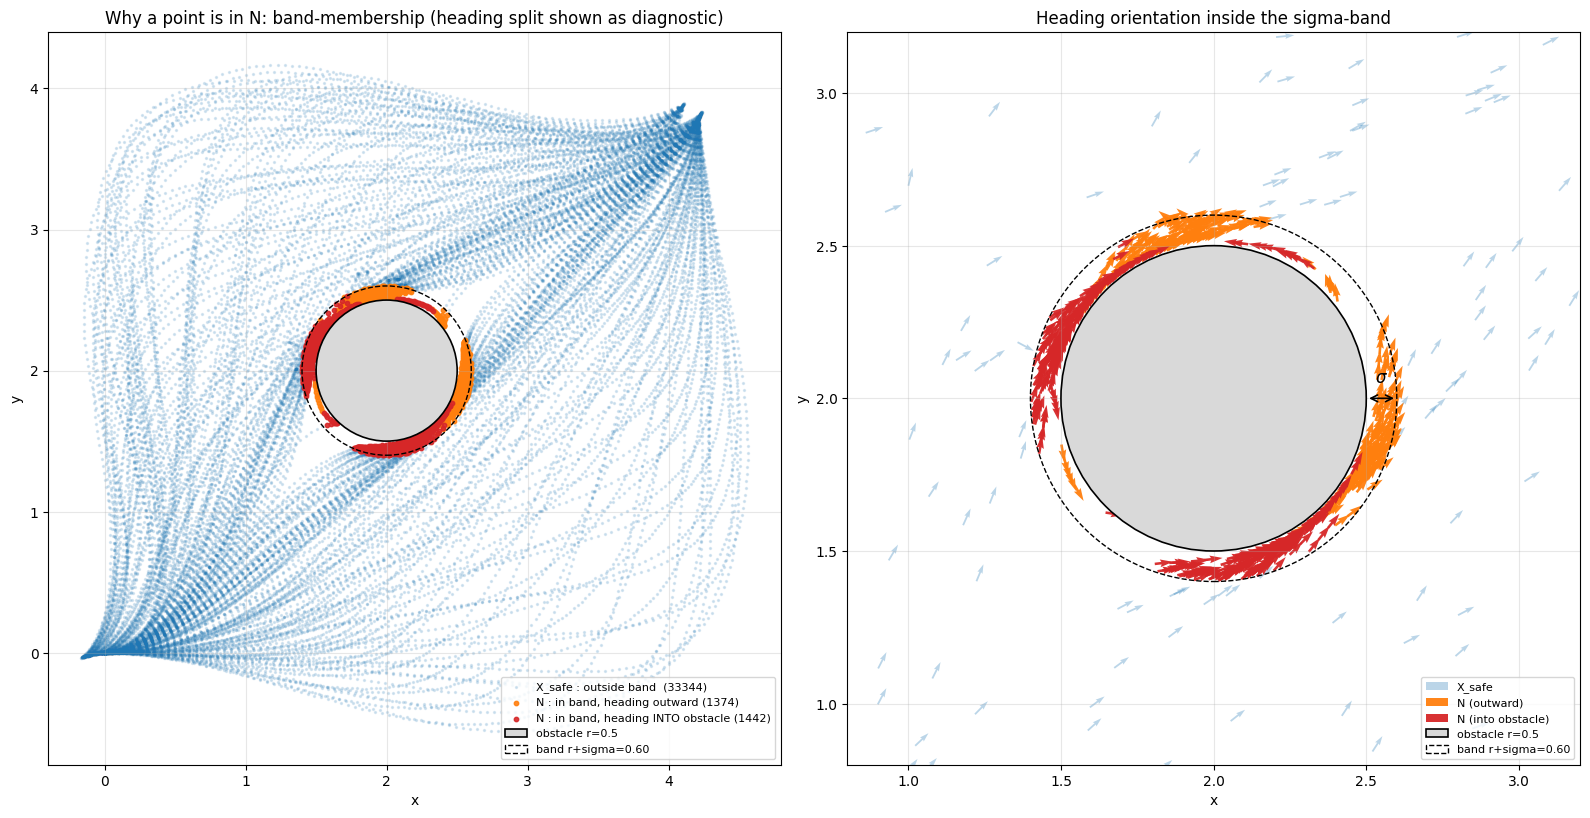

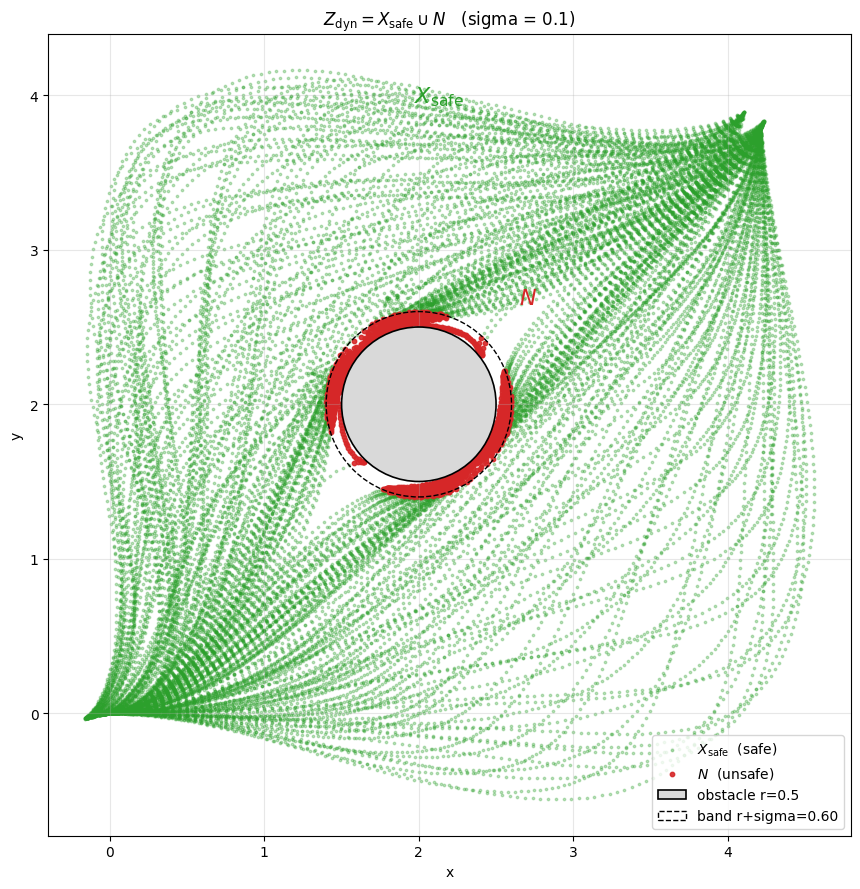

In [3]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyArrowPatch

# Recompute the diagnostic dot product for X_safe / N (heading . outward normal).
def _heading_dot_n(arr):
    dxp = arr[:, 0] - obs_cx
    dyp = arr[:, 1] - obs_cy
    d   = np.sqrt(dxp * dxp + dyp * dyp)
    nxp = np.where(d > 1e-12, dxp / np.maximum(d, 1e-12), 0.0)
    nyp = np.where(d > 1e-12, dyp / np.maximum(d, 1e-12), 0.0)
    return np.cos(arr[:, 2]) * nxp + np.sin(arr[:, 2]) * nyp

dot_N = _heading_dot_n(N)

def _draw_obstacle(ax):
    ax.add_patch(Circle((obs_cx, obs_cy), r_inner,
                        facecolor="0.85", edgecolor="k", lw=1.2, zorder=4,
                        label=f"obstacle r={r_inner}"))
    ax.add_patch(Circle((obs_cx, obs_cy), r_outer,
                        facecolor="none", edgecolor="k", lw=1.0, ls="--", zorder=4,
                        label=f"band r+sigma={r_outer:.2f}"))

# ---------------------------------------------------------------------------
# Figure 1: diagnostic - what condition placed each point where it is.
# Classification uses only band-membership; the heading split is informational.
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

ax = axes[0]
N_into = N[dot_N <  0.0]
N_away = N[dot_N >= 0.0]
ax.scatter(X_safe[:, 0], X_safe[:, 1], s=2, c="tab:blue", alpha=0.15,
           label=f"X_safe : outside band  ({len(X_safe)})")
ax.scatter(N_away[:, 0], N_away[:, 1], s=10, c="tab:orange", alpha=0.9,
           label=f"N : in band, heading outward ({len(N_away)})")
ax.scatter(N_into[:, 0], N_into[:, 1], s=10, c="tab:red", alpha=0.9,
           label=f"N : in band, heading INTO obstacle ({len(N_into)})")
_draw_obstacle(ax)
ax.set_aspect("equal"); ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_title("Why a point is in N: band-membership (heading split shown as diagnostic)")
ax.grid(alpha=0.3); ax.legend(loc="lower right", fontsize=8)

ax = axes[1]
def _sub(arr, k):
    if len(arr) <= k: return arr
    idx = np.random.default_rng(0).choice(len(arr), size=k, replace=False)
    return arr[idx]
S  = _sub(X_safe, 400)
Na = _sub(N_away, 400)
Ni = _sub(N_into, 400)
ax.quiver(S[:, 0],  S[:, 1],  np.cos(S[:, 2]),  np.sin(S[:, 2]),
          color="tab:blue",   alpha=0.30, scale=40, width=0.0025, label="X_safe")
ax.quiver(Na[:, 0], Na[:, 1], np.cos(Na[:, 2]), np.sin(Na[:, 2]),
          color="tab:orange", alpha=0.95, scale=40, width=0.0035, label="N (outward)")
ax.quiver(Ni[:, 0], Ni[:, 1], np.cos(Ni[:, 2]), np.sin(Ni[:, 2]),
          color="tab:red",    alpha=0.95, scale=40, width=0.0035, label="N (into obstacle)")
_draw_obstacle(ax)
# Annotate sigma with a radial arrow.
arr_patch = FancyArrowPatch((obs_cx + r_inner, obs_cy),
                            (obs_cx + r_outer, obs_cy),
                            arrowstyle="<->", mutation_scale=12,
                            color="k", lw=1.2, zorder=6)
ax.add_patch(arr_patch)
ax.text(obs_cx + r_inner + sigma / 2, obs_cy + 0.04, r"$\sigma$",
        ha="center", va="bottom", fontsize=12)
pad = 0.6
ax.set_xlim(obs_cx - r_outer - pad, obs_cx + r_outer + pad)
ax.set_ylim(obs_cy - r_outer - pad, obs_cy + r_outer + pad)
ax.set_aspect("equal"); ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_title("Heading orientation inside the sigma-band")
ax.grid(alpha=0.3); ax.legend(loc="lower right", fontsize=8)
plt.tight_layout(); plt.show()

# ---------------------------------------------------------------------------
# Figure 2: clean labeled plot - safe set X_safe vs unsafe set N
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 9))
ax.scatter(X_safe[:, 0], X_safe[:, 1], s=3, c="tab:green", alpha=0.30,
           label=r"$X_{\mathrm{safe}}$  (safe)")
ax.scatter(N[:, 0], N[:, 1], s=10, c="tab:red", alpha=0.9,
           label=r"$N$  (unsafe)")
_draw_obstacle(ax)
ax.annotate(r"$X_{\mathrm{safe}}$",
            xy=(X_safe[:, 0].mean(), X_safe[:, 1].max() * 0.95),
            fontsize=16, color="tab:green", weight="bold")
ax.annotate(r"$N$",
            xy=(obs_cx + r_outer + 0.05, obs_cy + r_outer + 0.05),
            fontsize=16, color="tab:red", weight="bold")
ax.set_aspect("equal"); ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_title(r"$Z_{\mathrm{dyn}} = X_{\mathrm{safe}} \cup N$"
             f"   (sigma = {sigma})")
ax.grid(alpha=0.3); ax.legend(loc="lower right")
plt.tight_layout(); plt.show()
